In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
import shutil
from datetime import datetime as dt

In [22]:
def create_bronze_df(df, source_file):
    df_bronze = df.copy()
    df_bronze['_ingestion_timestamp'] = dt.now()
    df_bronze['_source_file'] = source_file
    df_bronze['_week_day'] = df_bronze['_ingestion_timestamp'].day_name()
    return df_bronze

In [23]:
market_impact = pd.read_csv("Dados/originais/market_impact.csv")

In [24]:
market_impact.head(3)

,incident_id,stock_ticker,price_7d_before,price_disclosure_day,price_1d_after,price_7d_after,price_30d_after,volume_avg_30d_baseline,volume_disclosure_day,sector_index,...,p_value_30d,earnings_announcement_within_7d,market_cap_at_disclosure,volume_ratio_disclosure,pre_incident_volatility_30d,post_incident_volatility_30d,days_to_price_recovery,notes,created_at,updated_at
0,2023-0115-001,BITW,262.07,251.95,245.11,250.34,246.87,19782288,48767234,S&P 500 Information Technology,...,1.0000,True,1.181988e+11,2.4652,0.027705,0.052161,255.0,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
1,2021-0315-001,SFM,9.37,9.09,8.73,8.78,8.67,458826,1421143,S&P 500 Consumer Discretionary,...,0.9824,False,6.489114e+08,3.0973,0.017116,0.027638,324.0,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
2,2021-1204-001,SQI,14.60,13.36,13.09,13.28,13.17,230932,354433,S&P 500 Information Technology,...,1.0000,False,4.735164e+09,1.5348,0.038209,0.045756,19.0,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z


In [25]:
market_impact.isnull().sum()

incident_id                          0
stock_ticker                         0
price_7d_before                      0
price_disclosure_day                 0
price_1d_after                       0
price_7d_after                       0
price_30d_after                      0
volume_avg_30d_baseline              0
volume_disclosure_day                0
sector_index                         0
sector_return_same_period            0
abnormal_return_1d                   0
abnormal_return_7d                   0
abnormal_return_30d                  0
car_neg1_to_pos1                     0
car_0_to_7                           0
car_0_to_30                          0
car_0_to_90                          0
t_statistic_1d                       0
p_value_1d                           0
t_statistic_30d                      0
p_value_30d                          0
earnings_announcement_within_7d      0
market_cap_at_disclosure             0
volume_ratio_disclosure              0
pre_incident_volatility_3

In [26]:
market_impact.info()

<class 'pandas.DataFrame'>
RangeIndex: 358 entries, 0 to 357
Data columns (total 31 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   incident_id                      358 non-null    str    
 1   stock_ticker                     358 non-null    str    
 2   price_7d_before                  358 non-null    float64
 3   price_disclosure_day             358 non-null    float64
 4   price_1d_after                   358 non-null    float64
 5   price_7d_after                   358 non-null    float64
 6   price_30d_after                  358 non-null    float64
 7   volume_avg_30d_baseline          358 non-null    int64  
 8   volume_disclosure_day            358 non-null    int64  
 9   sector_index                     358 non-null    str    
 10  sector_return_same_period        358 non-null    float64
 11  abnormal_return_1d               358 non-null    float64
 12  abnormal_return_7d               

In [27]:
market_impact.describe()

,price_7d_before,price_disclosure_day,price_1d_after,price_7d_after,price_30d_after,volume_avg_30d_baseline,volume_disclosure_day,sector_return_same_period,abnormal_return_1d,abnormal_return_7d,...,car_0_to_90,t_statistic_1d,p_value_1d,t_statistic_30d,p_value_30d,market_cap_at_disclosure,volume_ratio_disclosure,pre_incident_volatility_30d,post_incident_volatility_30d,days_to_price_recovery
count,358.000000,358.000000,358.000000,358.000000,358.000000,3.580000e+02,3.580000e+02,358.000000,358.000000,358.000000,...,358.000000,358.000000,358.000000,358.000000,358.000000,3.580000e+02,358.000000,358.000000,358.000000,322.000000
mean,129.015642,124.754832,120.293268,120.945279,122.503631,3.556234e+06,9.897671e+06,0.004747,-0.034183,-0.030746,...,-0.012242,-2.594621,0.662270,-1.020512,0.888135,7.796113e+10,2.746851,0.023778,0.037085,109.866460
std,175.589952,169.632368,163.316301,164.186311,166.319908,7.377916e+06,2.063455e+07,0.014757,0.022088,0.026497,...,0.021135,2.172606,0.401876,1.739969,0.258872,1.356710e+11,0.722342,0.008535,0.014843,103.606842
min,5.080000,5.000000,4.610000,4.790000,4.990000,2.746300e+04,8.053000e+04,-0.019971,-0.098128,-0.106112,...,-0.095579,-15.612200,0.000200,-10.355500,0.000200,9.267550e+07,1.508100,0.010135,0.011879,5.000000
25%,13.257500,12.657500,12.110000,12.122500,12.447500,4.439210e+05,1.188034e+06,-0.008347,-0.049536,-0.046946,...,-0.024614,-3.467100,0.266450,-1.911025,0.986000,3.086725e+09,2.114125,0.016342,0.024839,28.000000
50%,43.515000,42.535000,41.050000,40.850000,41.575000,1.166098e+06,3.107902e+06,0.004854,-0.031195,-0.028201,...,-0.010039,-2.167200,0.916400,-0.879650,1.000000,1.929513e+10,2.753400,0.023608,0.034480,57.000000
75%,155.650000,149.607500,148.205000,147.845000,148.980000,2.963769e+06,7.480774e+06,0.018737,-0.018867,-0.010302,...,0.003258,-1.153600,1.000000,0.046925,1.000000,9.017196e+10,3.351200,0.030760,0.047426,177.000000
max,743.830000,741.520000,731.690000,734.290000,753.190000,6.688953e+07,1.728628e+08,0.029954,0.009984,0.025921,...,0.038986,1.185600,1.000000,4.671000,1.000000,1.059593e+12,3.993300,0.039934,0.077072,363.000000


In [28]:
market_impact_bronze = market_impact.apply(lambda x: create_bronze_df(x, "market_impact.csv"), axis=1)

In [29]:
if Path("Dados/bronze/market_impact_bronze.parquet").exists() :
    os.remove('Dados/bronze/market_impact_bronze.parquet')

In [30]:
Path('Dados/bronze').mkdir(parents=True,exist_ok=True)

In [31]:
if Path("Dados/bronze").exists():
    if not (Path("Dados/bronze/market_impact_bronze.parquet").exists()) :
        market_impact_bronze.to_parquet('market_impact_bronze.parquet')
        shutil.move('market_impact_bronze.parquet','Dados/bronze')

In [32]:
print(market_impact_bronze.isnull().sum()/market_impact_bronze.shape[0] * 100)

incident_id                         0.000000
stock_ticker                        0.000000
price_7d_before                     0.000000
price_disclosure_day                0.000000
price_1d_after                      0.000000
price_7d_after                      0.000000
price_30d_after                     0.000000
volume_avg_30d_baseline             0.000000
volume_disclosure_day               0.000000
sector_index                        0.000000
sector_return_same_period           0.000000
abnormal_return_1d                  0.000000
abnormal_return_7d                  0.000000
abnormal_return_30d                 0.000000
car_neg1_to_pos1                    0.000000
car_0_to_7                          0.000000
car_0_to_30                         0.000000
car_0_to_90                         0.000000
t_statistic_1d                      0.000000
p_value_1d                          0.000000
t_statistic_30d                     0.000000
p_value_30d                         0.000000
earnings_a

<Axes: >

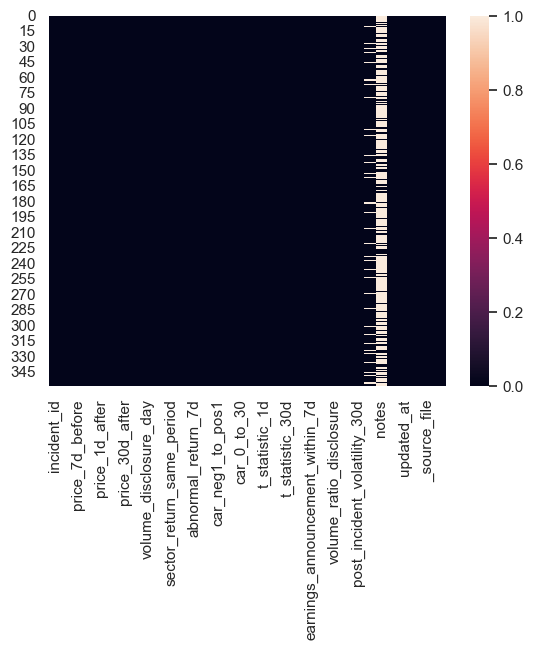

In [33]:
sns.heatmap(market_impact_bronze.isnull())

In [34]:
print(market_impact_bronze.duplicated(subset=['incident_id']).value_counts(),market_impact_bronze.duplicated().sum())

False    358
Name: count, dtype: int64 0


In [35]:
market_impact_bronze.dtypes

incident_id                                   str
stock_ticker                                  str
price_7d_before                           float64
price_disclosure_day                      float64
price_1d_after                            float64
price_7d_after                            float64
price_30d_after                           float64
volume_avg_30d_baseline                     int64
volume_disclosure_day                       int64
sector_index                                  str
sector_return_same_period                 float64
abnormal_return_1d                        float64
abnormal_return_7d                        float64
abnormal_return_30d                       float64
car_neg1_to_pos1                          float64
car_0_to_7                                float64
car_0_to_30                               float64
car_0_to_90                               float64
t_statistic_1d                            float64
p_value_1d                                float64


camada prata ==========================

In [36]:
def transformar_market_para_prata(df_bronze):
    df = df_bronze.copy()
    
    # 1. Remoção de Duplicidades (Exigência da Lauda)
    # Assumindo que haja um identificador único por empresa/incidente (ex: 'stock_ticker' ou 'incident_id' se houver)
    # Se não houver 'incident_id', podemos usar 'stock_ticker' e 'created_at' como chave combinada
    if 'incident_id' in df.columns:
        df = df.drop_duplicates(subset=['incident_id'], keep='last')
    elif 'stock_ticker' in df.columns and 'created_at' in df.columns:
        df = df.drop_duplicates(subset=['stock_ticker', 'created_at'], keep='last')

    # 2. Tratamento de Nulos (Exigência Crítica da Lauda)
    # Colunas financeiras e estatísticas: preenchemos com 0 (indicando que não houve variação/impacto registrado)
    colunas_financeiras = [
        'market_cap_at_disclosure', 'volume_ratio_disclosure', 
        'pre_incident_volatility_30d', 'post_incident_volatility_30d', 
        'days_to_price_recovery', 'car_0_to_30', 'abnormal_return_30d',
        't_statistic_30d', 'p_value_30d'
    ]
    for col in colunas_financeiras:
        if col in df.columns:
            df[col] = df[col].fillna(0)
            
    # Colunas categóricas e booleanas
    if 'earnings_announcement_within_7d' in df.columns:
        df['earnings_announcement_within_7d'] = df['earnings_announcement_within_7d'].fillna(False)
    
    if 'notes' in df.columns:
        df['notes'] = df['notes'].fillna('').astype(str).str.strip().str.lower()

    # 3. Tratamento de Datas (Exigência da Lauda)
    colunas_data = ['created_at', 'updated_at', 'disclosure_date'] # Ajustar se houver outras colunas de data
    for col in colunas_data:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors='coerce')

    # 4. Criação do Label final para Machine Learning (Exigência da Lauda)
    # Label: A empresa sofreu impacto prolongado na ação? (Demorou pelo menos 1 dia para recuperar o preço?)
    if 'days_to_price_recovery' in df.columns:
        df['label_recuperacao_lenta'] = np.where(df['days_to_price_recovery'] > 0, 1, 0)
    else:
        # Alternativa de label se a coluna acima falhar: Queda anormal nos 30 dias posteriores
        df['label_recuperacao_lenta'] = np.where(df['abnormal_return_30d'] < 0, 1, 0)

    # 5. Prevenção de Data Leakage (Exigência Crítica da Lauda)
    # Para prever ANTES do mercado reagir, não podemos usar métricas coletadas 30 dias DEPOIS do fato.
    colunas_leakage = [
        'days_to_price_recovery',        # É o próprio alvo
        'post_incident_volatility_30d',   # Só sabemos 30 dias depois do evento
        'abnormal_return_30d',            # Só sabemos 30 dias depois do evento
        't_statistic_30d',                # Estatística calculada a posteriori
        'p_value_30d',                    # Estatística calculada a posteriori
        'notes'                           # Pode conter revelações do resultado
    ]
    
    df_silver_completo = df.copy()
    df_silver_ml = df.drop(columns=[col for col in colunas_leakage if col in df.columns])
    
    return df_silver_completo, df_silver_ml


In [37]:
# Execução (Substitua 'market_impact_bronze' pela sua variável de DataFrame da Bronze)
market_silver_completo, market_silver_ml = transformar_market_para_prata(market_impact_bronze)

# Salvando em Parquet (atendendo à exigência da lauda)
market_silver_completo.to_parquet('market_impact_silver_completo.parquet', index=False)
market_silver_ml.to_parquet('market_impact_silver_ml.parquet', index=False)


In [38]:
if Path("Dados/prata/market_silver_completo.parquet").exists() :
    os.remove('Dados/prata/market_silver_completo.parquet')
    os.remove('Dados/prata/market_silver_ml.parquet')

Path('Dados/prata').mkdir(parents=True,exist_ok=True)


if Path("Dados/prata").exists():
    if not (Path("Dados/prata/market_silver_completo.parquet").exists()) :
        market_silver_completo.to_parquet('market_silver_completo.parquet', compression='snappy')
        shutil.move('market_silver_completo.parquet','Dados/prata')
        market_silver_ml.to_parquet('market_silver_ml.parquet', compression='snappy')
        shutil.move('market_silver_ml.parquet','Dados/prata')

C:\Users\dudup\AppData\Local\Temp\ipykernel_7052\6080615.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='label_recuperacao_lenta', data=market_silver_completo, palette='Set1')


Text(0, 0.5, 'Quantidade de Empresas')

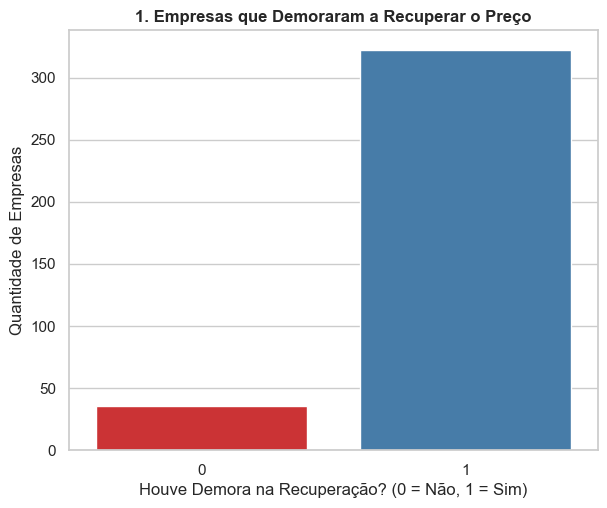

In [39]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 12))

# 1. Distribuição do Label (Frequência de Impacto Prolongado)
plt.subplot(2, 2, 1)
ax = sns.countplot(x='label_recuperacao_lenta', data=market_silver_completo, palette='Set1')
plt.title('1. Empresas que Demoraram a Recuperar o Preço', fontsize=12, fontweight='bold')
plt.xlabel('Houve Demora na Recuperação? (0 = Não, 1 = Sim)')
plt.ylabel('Quantidade de Empresas')

C:\Users\dudup\AppData\Local\Temp\ipykernel_7052\1080450745.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label_recuperacao_lenta', y='pre_incident_volatility_30d', data=market_silver_completo, palette='coolwarm')


Text(0, 0.5, 'Volatilidade Pré-Incidente (%)')

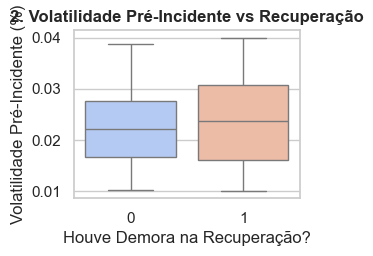

In [40]:
# 2. Boxplot: Volatilidade Pré-Incidente vs. Demora na Recuperação
plt.subplot(2, 2, 2)
sns.boxplot(x='label_recuperacao_lenta', y='pre_incident_volatility_30d', data=market_silver_completo, palette='coolwarm')
plt.title('2. Volatilidade Pré-Incidente vs Recuperação', fontsize=12, fontweight='bold')
plt.xlabel('Houve Demora na Recuperação?')
plt.ylabel('Volatilidade Pré-Incidente (%)')

Text(0, 0.5, 'Dias para Recuperação do Preço')

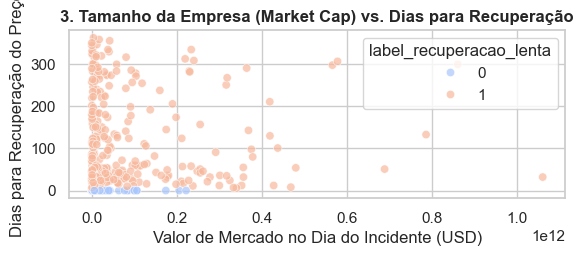

In [41]:
# 3. Dispersão: Valor de Mercado vs. Dias para Recuperação
plt.subplot(2, 1, 2)
# Filtrando valores zerados para melhor visualização
dispersao_df = market_silver_completo[market_silver_completo['market_cap_at_disclosure'] > 0]

sns.scatterplot(x='market_cap_at_disclosure', y='days_to_price_recovery', 
                hue='label_recuperacao_lenta', alpha=0.7, palette='coolwarm', data=dispersao_df)
plt.title('3. Tamanho da Empresa (Market Cap) vs. Dias para Recuperação', fontsize=12, fontweight='bold')
plt.xlabel('Valor de Mercado no Dia do Incidente (USD)')
plt.ylabel('Dias para Recuperação do Preço')